# Figure 5 — Pathway Enrichment Analysis

Mummichog pathway enrichment results for cassava and cocoyam, tested across four microbial metabolic models (Acetobacter, L. rhamnosus, L. plantarum, S. cerevisiae). Bubble plots show pathway significance per model; scatter plots show chemical subclass enrichment (lipid vs. non-lipid categories). Significance threshold: p < 0.1 with ≥ 2 pathway hits.

**Output:** `figure5_standardized.svg / .png`

In [1]:
# ── Imports & Configuration ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from adjustText import adjust_text
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION - edit paths and settings here
# ============================================================
CASSAVA_DIR = '../data/processed_data/b3_cassavaonly_biot/mummichog_extracted'
COCOYAM_DIR = '../data/processed_data/b3_cocoyamonly_biot/mummichog_extracted'

# Microbial metabolic models (folder suffix -> display label)
MICROBIAL_MODELS = ['acetobac', 'laccrh', 'lacpl', 'sackegg']
MODEL_LABELS = ['Acetobacter', 'L. rhamnosus', 'L. plantarum', 'S. cerevisiae']

# Chemical subclass model suffixes
SUBCLASS_LIP = 'sublip'
SUBCLASS_NONLIP = 'subnonlip'

# Output paths
OUTPUT_DIR = '../figures/separate_treatment'
SAVE_PNG = f'{OUTPUT_DIR}/figure5_pathway_enrichment.png'
SAVE_SVG = f'{OUTPUT_DIR}/figure5_pathway_enrichment.svg'

# Significance thresholds
P_THRESHOLD_MICRO = 0.1   # p-value threshold for microbial models
P_THRESHOLD_SUB = 0.05    # p-value threshold for subclass scatter
MIN_HITS = 2              # minimum hits for significance

print("✅ Configuration loaded")

✅ Configuration loaded


In [2]:
# ── Load Mummichog Results ─────────────────────────────────────────────────────

def load_mummichog(base, model):
    """Load and preprocess mummichog pathway enrichment results."""
    # File pattern: Download_001_{model}/mummichog_pathway_enrichment_mummichog.csv
    filepath = f'{base}/Download_001_{model}/mummichog_pathway_enrichment_mummichog.csv'
    df = pd.read_csv(filepath, index_col=0)
    df['ER'] = df['Hits.sig'] / df['Expected']  # Enrichment Ratio
    df['ER'] = df['ER'].replace([np.inf], np.nan)
    df['nlp'] = -np.log10(df['P(Fisher)'].clip(lower=1e-300))  # -log10(p)
    return df

# Load microbial model results
cassava_micro = {m: load_mummichog(CASSAVA_DIR, m) for m in MICROBIAL_MODELS}
cocoyam_micro = {m: load_mummichog(COCOYAM_DIR, m) for m in MICROBIAL_MODELS}

# Load chemical subclass results
cassava_lip = load_mummichog(CASSAVA_DIR, SUBCLASS_LIP)
cassava_nonlip = load_mummichog(CASSAVA_DIR, SUBCLASS_NONLIP)
cocoyam_lip = load_mummichog(COCOYAM_DIR, SUBCLASS_LIP)
cocoyam_nonlip = load_mummichog(COCOYAM_DIR, SUBCLASS_NONLIP)

print(f"✅ Loaded data for {len(MICROBIAL_MODELS)} microbial models + 2 subclass models")
print(f"   Cassava pathways: {len(cassava_micro[MICROBIAL_MODELS[0]])} | Cocoyam: {len(cocoyam_micro[MICROBIAL_MODELS[0]])}")

✅ Loaded data for 4 microbial models + 2 subclass models
   Cassava pathways: 55 | Cocoyam: 21


## Panels A & B: Microbial Model Pathway Enrichment

Select pathways significant in at least one microbial model and build matrices for bubble plot.

In [3]:
# ── Process Pathway Data for Bubble Grid ───────────────────────────────────────

# Find pathways significant in at least one model (p < 0.1, hits >= 2)
sig_pathways = set()
nlp_threshold = -np.log10(P_THRESHOLD_MICRO)  # 1.0 for p=0.1

for m in MICROBIAL_MODELS:
    for micro_dict in [cassava_micro, cocoyam_micro]:
        df = micro_dict[m]
        sig = df[(df['nlp'] >= nlp_threshold) & (df['Hits.sig'] >= MIN_HITS)]
        sig_pathways.update(sig.index)

pathway_list = sorted(sig_pathways)
print(f"📊 Found {len(pathway_list)} significant pathways across all models")

def build_matrix(micro_dict, pathways):
    """Build -log10(p) and hits matrices for bubble plot."""
    nlp = pd.DataFrame(0.0, index=pathways, columns=MICROBIAL_MODELS)
    hits = pd.DataFrame(0.0, index=pathways, columns=MICROBIAL_MODELS)
    for m in MICROBIAL_MODELS:
        df = micro_dict[m]
        for pw in pathways:
            if pw in df.index:
                nlp.loc[pw, m] = df.loc[pw, 'nlp']
                hits.loc[pw, m] = df.loc[pw, 'Hits.sig']
    return nlp, hits

cas_nlp, cas_hits = build_matrix(cassava_micro, pathway_list)
coc_nlp, coc_hits = build_matrix(cocoyam_micro, pathway_list)

# Sort pathways by max -log10(p) across both tubers
best = pd.concat([cas_nlp.max(axis=1), coc_nlp.max(axis=1)], axis=1).max(axis=1)
pathway_order = best.sort_values(ascending=True).index.tolist()

cas_nlp = cas_nlp.loc[pathway_order]
cas_hits = cas_hits.loc[pathway_order]
coc_nlp = coc_nlp.loc[pathway_order]
coc_hits = coc_hits.loc[pathway_order]

print(f"✅ Matrices built: {len(pathway_order)} pathways × {len(MICROBIAL_MODELS)} models")

📊 Found 7 significant pathways across all models
✅ Matrices built: 7 pathways × 4 models


## Panels C & D: Chemical Subclass Enrichment

Combine lipid and non-lipid subclass results for scatter plot visualization.

In [4]:
# ── Process Chemical Subclass Data ─────────────────────────────────────────────

def combine_subclass(lip_df, nonlip_df, min_hits=MIN_HITS):
    """Combine lipid and non-lipid subclass results."""
    lip = lip_df[lip_df['Hits.sig'] >= min_hits].copy()
    lip['source'] = 'Lipid'
    nonlip = nonlip_df[nonlip_df['Hits.sig'] >= min_hits].copy()
    nonlip['source'] = 'Non-lipid'
    return pd.concat([lip, nonlip])

cas_sub = combine_subclass(cassava_lip, cassava_nonlip)
coc_sub = combine_subclass(cocoyam_lip, cocoyam_nonlip)

# Count significant subclasses
nlp_sig_threshold = -np.log10(P_THRESHOLD_SUB)
cas_sig = cas_sub[cas_sub['nlp'] >= nlp_sig_threshold]
coc_sig = coc_sub[coc_sub['nlp'] >= nlp_sig_threshold]

print(f"📊 Cassava subclasses: {len(cas_sub)} total, {len(cas_sig)} significant (p<{P_THRESHOLD_SUB})")
print(f"📊 Cocoyam subclasses: {len(coc_sub)} total, {len(coc_sig)} significant (p<{P_THRESHOLD_SUB})")

📊 Cassava subclasses: 155 total, 27 significant (p<0.05)
📊 Cocoyam subclasses: 102 total, 12 significant (p<0.05)


## Plotting Functions

Define reusable plotting functions for bubble grid and scatter plots.

In [5]:
# ── Plotting Functions ─────────────────────────────────────────────────────────

# Color scheme
SIG_COLOR = '#D35400'      # Orange for significant
NONSIG_COLOR = '#C0C0C0'   # Gray for non-significant
LIPID_COLOR = '#3498DB'    # Blue for lipids
NONLIPID_COLOR = '#E74C3C' # Red for non-lipids

def plot_bubble_grid(ax, nlp_mat, hits_mat, show_ylabels=True):
    """Plot bubble grid for pathway enrichment across models."""
    n_pw = len(nlp_mat)
    n_mod = len(MICROBIAL_MODELS)
    threshold = -np.log10(P_THRESHOLD_MICRO)
    
    for i, pw in enumerate(nlp_mat.index):
        for j, m in enumerate(MICROBIAL_MODELS):
            pv = float(nlp_mat.loc[pw, m])
            nh = float(hits_mat.loc[pw, m])
            
            if nh < MIN_HITS or pv == 0:
                # Empty/non-significant placeholder
                ax.scatter(j, i, s=15, color='#F0F0F0', edgecolors='#E0E0E0',
                          linewidth=0.3, zorder=2)
                continue
            
            size = np.clip(pv * 100, 30, 500)
            if pv >= threshold:
                ax.scatter(j, i, s=size, color=SIG_COLOR, edgecolors='#8B2500',
                          linewidth=0.7, alpha=0.85, zorder=3)
            else:
                ax.scatter(j, i, s=size, color=NONSIG_COLOR, edgecolors='#999999',
                          linewidth=0.5, alpha=0.5, zorder=3)

    ax.set_xticks(range(n_mod))
    ax.set_xticklabels(MODEL_LABELS, rotation=90, ha='center', fontsize=10.5, fontstyle='italic')
    ax.set_yticks(range(n_pw))
    if show_ylabels:
        ax.set_yticklabels(nlp_mat.index, fontsize=10.5)
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-0.5, n_mod - 0.5)
    ax.set_ylim(-0.5, n_pw - 0.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color('#CCCCCC')
    ax.tick_params(length=3)
    
    # Horizontal grid lines
    for i in range(n_pw):
        ax.axhline(y=i, color='#F0F0F0', linewidth=0.4, zorder=1)


def plot_subclass_scatter(ax, sub_df):
    """Plot scatter plot for chemical subclass enrichment."""
    p_line = -np.log10(P_THRESHOLD_SUB)
    colors = {'Lipid': LIPID_COLOR, 'Non-lipid': NONLIPID_COLOR}
    BUBBLE_SIZE = 80  # Fixed bubble size

    for source, group in sub_df.groupby('source'):
        sig = group['nlp'] >= p_line
        
        # Non-significant points (faded)
        if (~sig).any():
            ax.scatter(group.loc[~sig, 'ER'], group.loc[~sig, 'nlp'],
                      s=BUBBLE_SIZE, color=colors[source], alpha=0.2,
                      edgecolors='none', zorder=2)
        # Significant points
        if sig.any():
            ax.scatter(group.loc[sig, 'ER'], group.loc[sig, 'nlp'],
                      s=BUBBLE_SIZE, color=colors[source], alpha=0.7,
                      edgecolors=colors[source], linewidth=0.5, zorder=3)

    # Significance threshold line
    ax.axhline(y=p_line, color='black', linestyle='--', linewidth=0.7, alpha=0.5)

    # Label top significant subclasses
    sig_df = sub_df[sub_df['nlp'] >= p_line].copy()
    if len(sig_df) > 0:
        top = sig_df.nlargest(min(10, len(sig_df)), 'nlp')
        for idx, row in top.iterrows():
            name = idx if len(idx) <= 28 else idx[:25] + '...'
            c = colors[row['source']]
            ax.annotate(name, (row['ER'], row['nlp']), 
                       xytext=(5, 3), textcoords='offset points',
                       fontsize=8.5, color=c, fontweight='bold')

    ax.set_xlabel('Enrichment Factor', fontsize=11)
    ax.set_ylabel('–log₁₀(p-value)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10.5)

    # Axis limits
    er_sig = sub_df.loc[sub_df['nlp'] >= p_line, 'ER'].dropna()
    x_max = er_sig.max() * 1.15 if len(er_sig) > 0 else sub_df['ER'].quantile(0.95) * 1.3
    ax.set_xlim(0, max(x_max, 5))
    ylim = ax.get_ylim()
    ax.set_ylim(0, ylim[1] * 1.1)

    # Legend for lipid/non-lipid only
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=LIPID_COLOR, markersize=9, label='Lipid'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=NONLIPID_COLOR, markersize=9, label='Non-lipid'),
    ]
    
    ax.legend(handles=handles, loc='upper right', fontsize=9.5,
             frameon=True, fancybox=False, edgecolor='#CCCCCC')

print("✅ Plotting functions defined")

✅ Plotting functions defined


## Generate Figure 5

Create the final 4-panel figure combining all pathway enrichment visualizations.

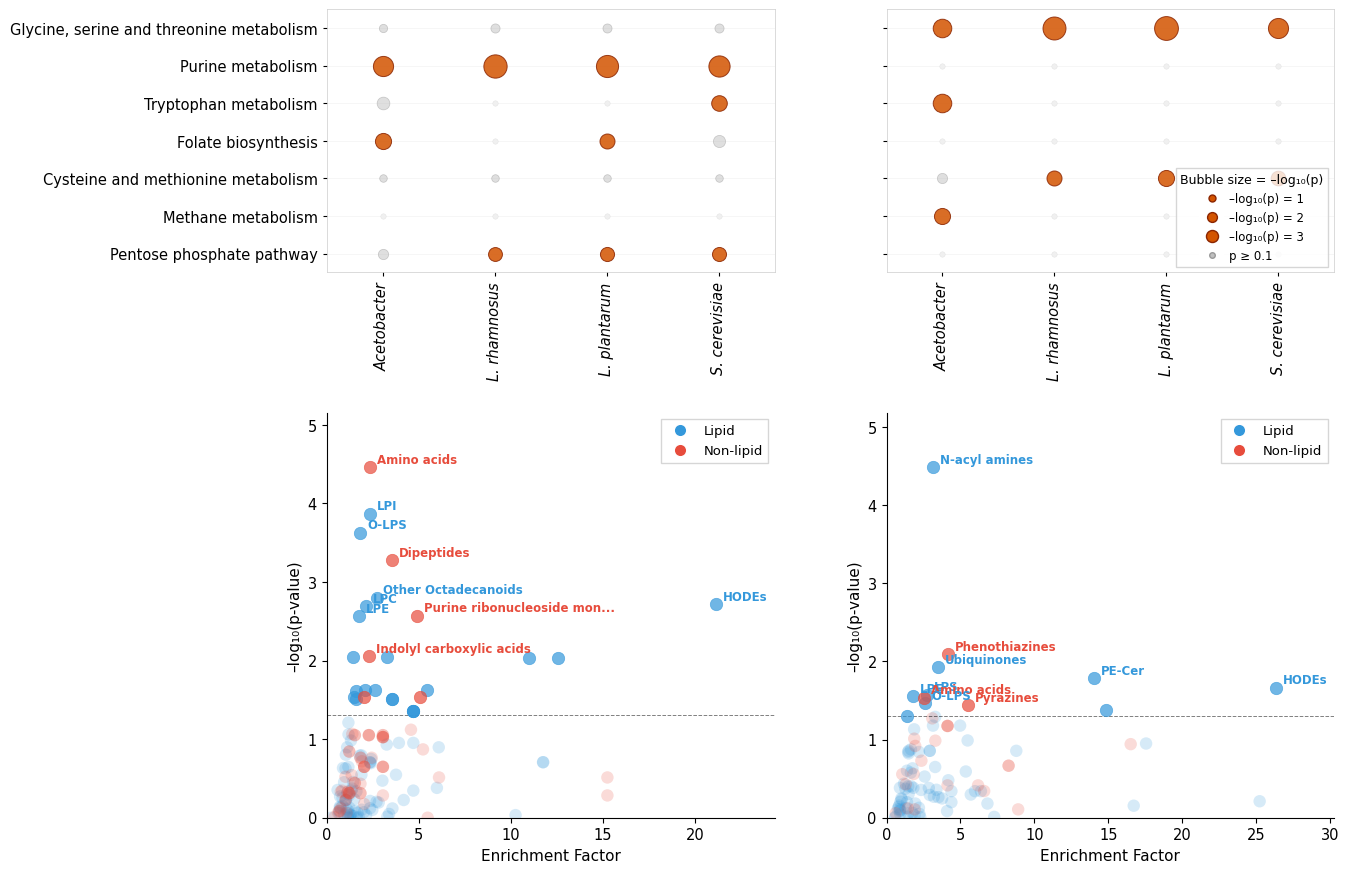


✅ Figure saved to:
   ../figures/separate_treatment/figure5_pathway_enrichment.png
   ../figures/separate_treatment/figure5_pathway_enrichment.svg


In [6]:
# ── Generate Figure 5 ──────────────────────────────────────────────────────────
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set up matplotlib style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 16,
    'axes.linewidth': 0.8,
})

# Create figure with 2x2 grid
fig = plt.figure(figsize=(13, 10.5))
gs = gridspec.GridSpec(2, 2, height_ratios=[0.65, 1], hspace=0.42, wspace=0.25)

# ── Panel A: Cassava Microbial Models (with y-labels) ──
ax1 = fig.add_subplot(gs[0, 0])
plot_bubble_grid(ax1, cas_nlp, cas_hits, show_ylabels=True)

# ── Panel B: Cocoyam Microbial Models (no y-labels) ──
ax2 = fig.add_subplot(gs[0, 1])
plot_bubble_grid(ax2, coc_nlp, coc_hits, show_ylabels=False)

# Add bubble size legend to Panel B
sizes_demo = [1.0, 2.0, 3.0]
bleg = []
for s in sizes_demo:
    ms = np.sqrt(np.clip(s * 100, 30, 500)) / 2
    bleg.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=SIG_COLOR,
                       markeredgecolor='#8B2500', markersize=ms,
                       label=f'–log₁₀(p) = {s:.0f}'))
bleg.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=NONSIG_COLOR,
                   markeredgecolor='#999999', markersize=4, label='p ≥ 0.1'))
ax2.legend(handles=bleg, loc='lower right', fontsize=8.5, frameon=True,
           fancybox=False, edgecolor='#CCCCCC', title='Bubble size = –log₁₀(p)',
           title_fontsize=9, handletextpad=0.5)

# ── Panel C: Cassava Chemical Subclasses ──
ax3 = fig.add_subplot(gs[1, 0])
plot_subclass_scatter(ax3, cas_sub)

# ── Panel D: Cocoyam Chemical Subclasses ──
ax4 = fig.add_subplot(gs[1, 1])
plot_subclass_scatter(ax4, coc_sub)

# Save figure
plt.savefig(SAVE_PNG, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(SAVE_SVG, format='svg', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Figure saved to:")
print(f"   {SAVE_PNG}")
print(f"   {SAVE_SVG}")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


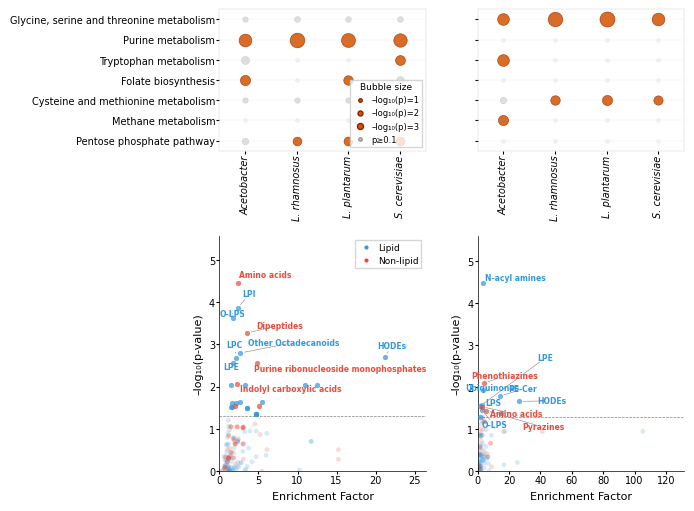


✅ Compact 6×6 figure saved to ../figures/separate_treatment


In [7]:
# ── EXPERIMENTAL: Compact 6x6 Figure ───────────────────────────────────────────
# Denser layout with adjusted font sizes for better legibility at smaller size

import os
from pathlib import Path
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Compact style settings - slightly larger fonts for legibility
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 9,
    'axes.linewidth': 0.5,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'legend.title_fontsize': 7,
})

# Create compact 6x6 figure
fig = plt.figure(figsize=(6, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[0.6, 1], hspace=0.45, wspace=0.25)

# ── Helper: Compact bubble grid ──
def plot_bubble_grid_compact(ax, nlp_mat, hits_mat, show_ylabels=True):
    """Compact bubble grid for 6x6 figure."""
    n_pw = len(nlp_mat)
    n_mod = len(MICROBIAL_MODELS)
    threshold = -np.log10(P_THRESHOLD_MICRO)
    
    for i, pw in enumerate(nlp_mat.index):
        for j, m in enumerate(MICROBIAL_MODELS):
            pv = float(nlp_mat.loc[pw, m])
            nh = float(hits_mat.loc[pw, m])
            
            if nh < MIN_HITS or pv == 0:
                ax.scatter(j, i, s=8, color='#F0F0F0', edgecolors='#E0E0E0',
                          linewidth=0.2, zorder=2)
                continue
            
            size = np.clip(pv * 40, 15, 200)  # Smaller bubbles
            if pv >= threshold:
                ax.scatter(j, i, s=size, color=SIG_COLOR, edgecolors='#8B2500',
                          linewidth=0.4, alpha=0.85, zorder=3)
            else:
                ax.scatter(j, i, s=size, color=NONSIG_COLOR, edgecolors='#999999',
                          linewidth=0.3, alpha=0.5, zorder=3)

    ax.set_xticks(range(n_mod))
    ax.set_xticklabels(MODEL_LABELS, rotation=90, ha='center', fontsize=7, fontstyle='italic')
    ax.set_yticks(range(n_pw))
    if show_ylabels:
        ax.set_yticklabels(nlp_mat.index, fontsize=7)
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-0.5, n_mod - 0.5)
    ax.set_ylim(-0.5, n_pw - 0.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
        spine.set_color('#CCCCCC')
    ax.tick_params(length=2, pad=1)
    
    for i in range(n_pw):
        ax.axhline(y=i, color='#F0F0F0', linewidth=0.3, zorder=1)

# ── Helper: Compact scatter plot ──
def plot_subclass_scatter_compact(ax, sub_df, show_legend=True):
    """Compact scatter plot for 6x6 figure."""
    p_line = -np.log10(P_THRESHOLD_SUB)
    colors = {'Lipid': LIPID_COLOR, 'Non-lipid': NONLIPID_COLOR}
    BUBBLE_SIZE = 12  # Smaller bubbles

    for source, group in sub_df.groupby('source'):
        sig = group['nlp'] >= p_line
        if (~sig).any():
            ax.scatter(group.loc[~sig, 'ER'], group.loc[~sig, 'nlp'],
                      s=BUBBLE_SIZE, color=colors[source], alpha=0.2,
                      edgecolors='none', zorder=2)
        if sig.any():
            ax.scatter(group.loc[sig, 'ER'], group.loc[sig, 'nlp'],
                      s=BUBBLE_SIZE, color=colors[source], alpha=0.7,
                      edgecolors=colors[source], linewidth=0.3, zorder=3)

    ax.axhline(y=p_line, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

    # Set axis limits FIRST with extra padding for labels
    er_all = sub_df['ER'].dropna()
    x_max = er_all.max() * 1.25 if len(er_all) > 0 else 5  # More padding for labels
    ax.set_xlim(0, x_max)
    
    nlp_max = sub_df['nlp'].max()
    ax.set_ylim(0, nlp_max * 1.25)  # More padding at top

    # Label top significant subclasses with adjust_text
    sig_df = sub_df[sub_df['nlp'] >= p_line].copy()
    texts = []
    if len(sig_df) > 0:
        top = sig_df.nlargest(min(10, len(sig_df)), 'nlp')
        for idx, row in top.iterrows():
            # Use full name - no truncation
            name = idx
            c = colors[row['source']]
            txt = ax.text(row['ER'], row['nlp'], name,
                         fontsize=5.5, color=c, fontweight='bold')
            texts.append(txt)
        
        # Use adjust_text to spread labels and add connector lines
        adjust_text(texts, ax=ax, 
                   arrowprops=dict(arrowstyle='-', color='gray', lw=0.4, shrinkA=5, shrinkB=3),
                   expand_points=(1.8, 1.8),
                   force_points=(0.8, 0.8),
                   force_text=(0.5, 0.5),
                   lim=100)

    ax.set_xlabel('Enrichment Factor', fontsize=8)
    ax.set_ylabel('–log₁₀(p-value)', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7, length=2, pad=1)

    if show_legend:
        handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=LIPID_COLOR, markersize=4, label='Lipid'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=NONLIPID_COLOR, markersize=4, label='Non-lipid'),
        ]
        ax.legend(handles=handles, loc='upper right', fontsize=6.5,
                 frameon=True, fancybox=False, edgecolor='#CCCCCC',
                 handletextpad=0.3, borderpad=0.3)

# ── Panel A: Cassava (with y-labels) ──
ax1 = fig.add_subplot(gs[0, 0])
plot_bubble_grid_compact(ax1, cas_nlp, cas_hits, show_ylabels=True)

# Add bubble size legend to Panel A (left)
sizes_demo = [1.0, 2.0, 3.0]
bleg = []
for s in sizes_demo:
    ms = np.sqrt(np.clip(s * 40, 15, 200)) / 2.5
    bleg.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=SIG_COLOR,
                       markeredgecolor='#8B2500', markersize=ms,
                       label=f'–log₁₀(p)={s:.0f}'))
bleg.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=NONSIG_COLOR,
                   markeredgecolor='#999999', markersize=2.5, label='p≥0.1'))
ax1.legend(handles=bleg, loc='lower right', fontsize=6, frameon=True,
           fancybox=False, edgecolor='#CCCCCC', title='Bubble size',
           title_fontsize=6.5, handletextpad=0.3, borderpad=0.3)

# ── Panel B: Cocoyam (no y-labels, no legend) ──
ax2 = fig.add_subplot(gs[0, 1])
plot_bubble_grid_compact(ax2, coc_nlp, coc_hits, show_ylabels=False)

# ── Panel C: Cassava Subclasses (with legend) ──
ax3 = fig.add_subplot(gs[1, 0])
plot_subclass_scatter_compact(ax3, cas_sub, show_legend=True)

# ── Panel D: Cocoyam Subclasses (no legend) ──
ax4 = fig.add_subplot(gs[1, 1])
plot_subclass_scatter_compact(ax4, coc_sub, show_legend=False)

plt.tight_layout()
out_path = Path(OUTPUT_DIR)
plt.savefig(out_path / 'mummichog_enrichment_6x6.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_path / 'mummichog_enrichment_6x6.svg', format='svg', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Compact 6×6 figure saved to {OUTPUT_DIR}")

## Figure 5 — Standardized & Harmonized

Publication-ready version matching Figure 1 & 2 style standards (LABEL_FONTSIZE=20, TICK_FONTSIZE=20, LEGEND_FONTSIZE=18, PANEL_LABEL_FONTSIZE=28, SPINE_WIDTH=2.5, bold labels).

✅ Standardized plotting functions defined


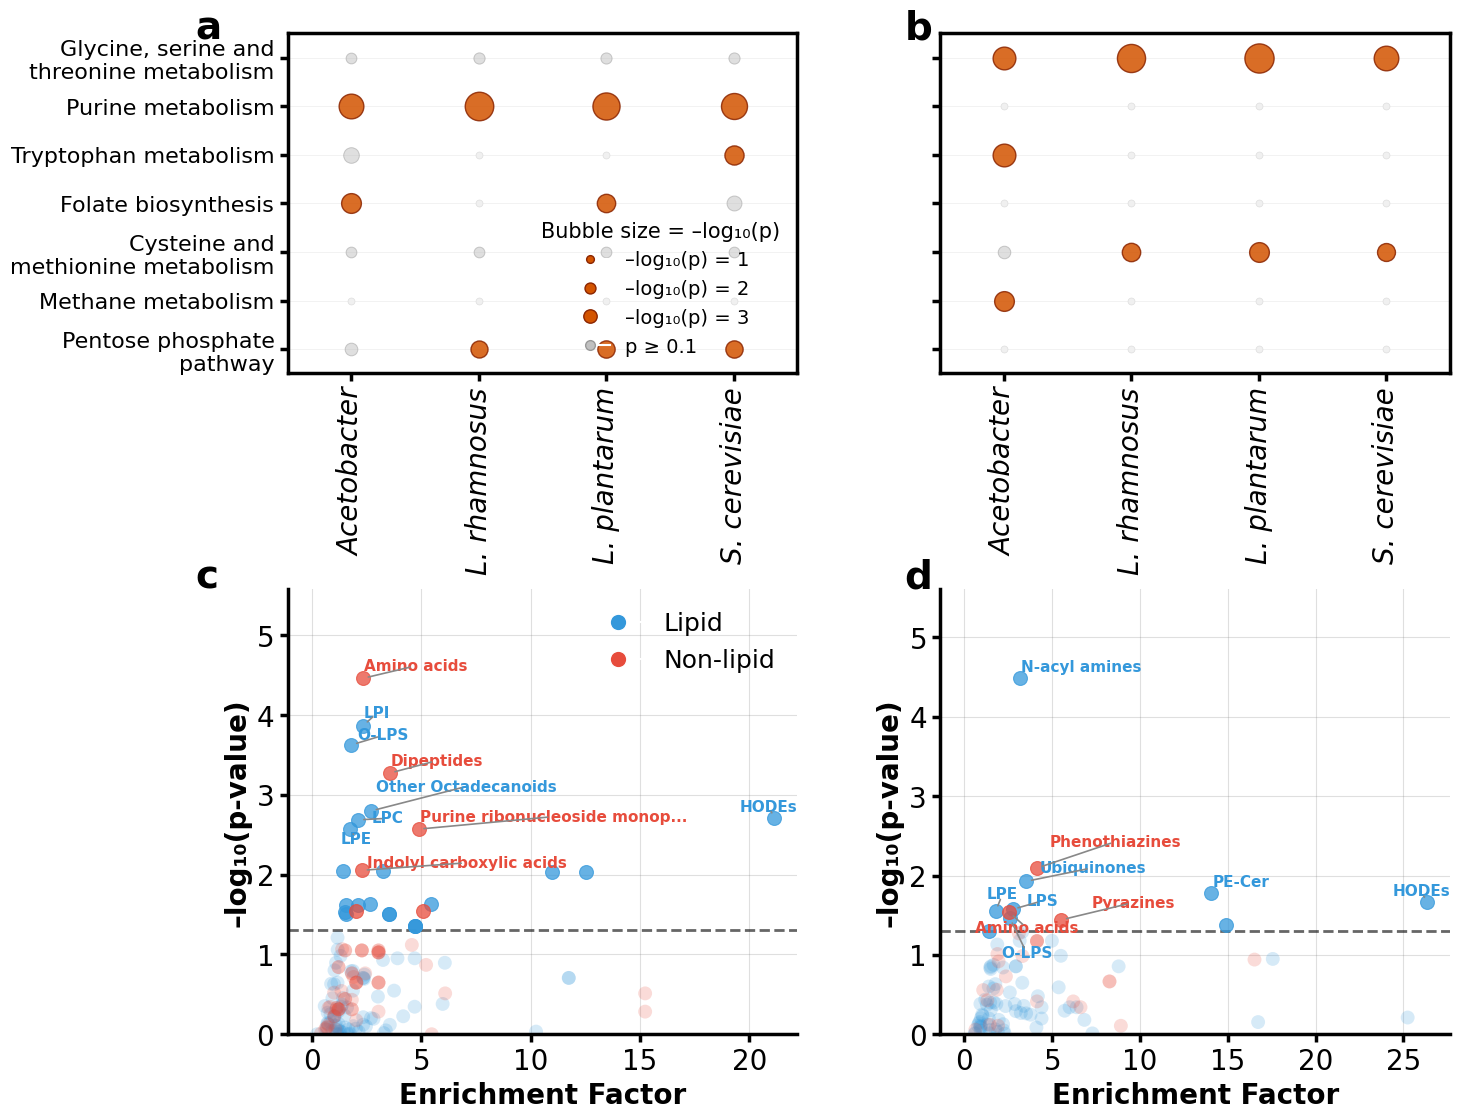


✅ Figure 5 (standardized) saved:
   ../figures/separate_treatment/figure5_standardized.png
   ../figures/separate_treatment/figure5_standardized.svg


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: STANDARDIZED & HARMONIZED VERSION
# Matching the publication-ready style from Figure 1 & 2
# ═══════════════════════════════════════════════════════════════════════════════

import os, textwrap
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── STYLING PARAMETERS (matching Figure 1 & 2 standards) ───────────────────
LABEL_FONTSIZE       = 20
TICK_FONTSIZE        = 20
YLABEL_FONTSIZE      = 16   # slightly smaller for wrapped pathway names
LEGEND_FONTSIZE      = 18
PANEL_LABEL_FONTSIZE = 28
SPINE_WIDTH          = 2.5
GRID_ALPHA           = 0.25

# ─── COLOR SCHEME ────────────────────────────────────────────────────────────
SIG_COLOR_STD      = '#D35400'
NONSIG_COLOR_STD   = '#C0C0C0'
LIPID_COLOR_STD    = '#3498DB'
NONLIPID_COLOR_STD = '#E74C3C'

plt.rcParams.update({
    'font.family'    : 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size'      : TICK_FONTSIZE,
    'axes.linewidth' : SPINE_WIDTH,
})

# ═════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ═════════════════════════════════════════════════════════════════════════════

def wrap_pathway(name, width=22):
    """Wrap a pathway name at word boundaries to at most `width` chars per line."""
    return textwrap.fill(name, width=width)


def plot_bubble_grid_std(ax, nlp_mat, hits_mat, show_ylabels=True):
    """Publication-ready bubble grid for pathway enrichment across models."""
    n_pw  = len(nlp_mat)
    n_mod = len(MICROBIAL_MODELS)
    threshold = -np.log10(P_THRESHOLD_MICRO)

    for i, pw in enumerate(nlp_mat.index):
        for j, m in enumerate(MICROBIAL_MODELS):
            pv = float(nlp_mat.loc[pw, m])
            nh = float(hits_mat.loc[pw, m])

            if nh < MIN_HITS or pv == 0:
                ax.scatter(j, i, s=25, color='#F0F0F0', edgecolors='#DDDDDD',
                           linewidth=0.5, zorder=2)
                continue

            size = np.clip(pv * 150, 60, 800)
            if pv >= threshold:
                ax.scatter(j, i, s=size, color=SIG_COLOR_STD,
                           edgecolors='#8B2500', linewidth=1.0, alpha=0.85, zorder=3)
            else:
                ax.scatter(j, i, s=size, color=NONSIG_COLOR_STD,
                           edgecolors='#999999', linewidth=0.7, alpha=0.5, zorder=3)

    ax.set_xticks(range(n_mod))
    ax.set_xticklabels(MODEL_LABELS, rotation=90, ha='center',
                       fontsize=TICK_FONTSIZE, fontstyle='italic')
    ax.set_yticks(range(n_pw))
    if show_ylabels:
        wrapped = [wrap_pathway(pw) for pw in nlp_mat.index]
        ax.set_yticklabels(wrapped, fontsize=YLABEL_FONTSIZE, linespacing=1.2)
    else:
        ax.set_yticklabels([])

    ax.set_xlim(-0.5, n_mod - 0.5)
    ax.set_ylim(-0.5, n_pw - 0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)
        spine.set_edgecolor('black')
    ax.tick_params(length=6, width=SPINE_WIDTH)

    for i in range(n_pw):
        ax.axhline(y=i, color='#F0F0F0', linewidth=0.6, zorder=1)


def plot_subclass_scatter_std(ax, sub_df, show_legend=True):
    """Publication-ready scatter plot for chemical subclass enrichment."""
    p_line = -np.log10(P_THRESHOLD_SUB)
    colors = {'Lipid': LIPID_COLOR_STD, 'Non-lipid': NONLIPID_COLOR_STD}
    BSIZE  = 100

    for source, group in sub_df.groupby('source'):
        sig = group['nlp'] >= p_line
        col = colors[source]
        if (~sig).any():
            ax.scatter(group.loc[~sig, 'ER'], group.loc[~sig, 'nlp'],
                       s=BSIZE, color=col, alpha=0.2, edgecolors='none', zorder=2)
        if sig.any():
            ax.scatter(group.loc[sig, 'ER'], group.loc[sig, 'nlp'],
                       s=BSIZE, color=col, alpha=0.75,
                       edgecolors=col, linewidth=0.8, zorder=3)

    ax.axhline(y=p_line, color='black', linestyle='--', linewidth=2, alpha=0.6)

    # Axis limits: tight around significant data, symmetric left pad to align with A/B
    sig_df_all = sub_df[sub_df['nlp'] >= p_line].dropna(subset=['ER', 'nlp'])
    er_sig = sig_df_all['ER']
    if len(er_sig) > 0:
        x_max = max(np.percentile(er_sig, 95) * 1.15, er_sig.max() * 1.05)
    else:
        x_max = sub_df['ER'].quantile(0.95) * 1.2
    x_max  = max(x_max, 5)
    x_left = -x_max * 0.05
    ax.set_xlim(x_left, x_max)

    y_max = sig_df_all['nlp'].max() if len(sig_df_all) > 0 else sub_df['nlp'].max()
    ax.set_ylim(0, y_max * 1.25)

    # Labels with adjust_text + connector lines
    texts = []
    if len(sig_df_all) > 0:
        top = sig_df_all.nlargest(min(10, len(sig_df_all)), 'nlp')
        for idx, row in top.iterrows():
            name = idx if len(idx) <= 30 else idx[:27] + '...'
            txt = ax.text(row['ER'], row['nlp'], name,
                          fontsize=11, color=colors[row['source']],
                          fontweight='bold', va='bottom', ha='left')
            texts.append(txt)

        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#888888', lw=1.2,
                            shrinkA=4, shrinkB=4),
            expand_points=(1.5, 1.5),
            expand_text=(1.3, 1.3),
            force_points=(0.6, 0.8),
            force_text=(0.5, 0.6),
            lim=200,
        )

    ax.set_xlabel('Enrichment Factor', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylabel('–log₁₀(p-value)',   fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(SPINE_WIDTH)
        ax.spines[spine].set_edgecolor('black')
    ax.tick_params(labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
    ax.grid(axis='both', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
    ax.set_axisbelow(True)

    if show_legend:
        handles = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=LIPID_COLOR_STD, markersize=12, label='Lipid'),
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=NONLIPID_COLOR_STD, markersize=12, label='Non-lipid'),
        ]
        ax.legend(handles=handles, loc='upper right', fontsize=LEGEND_FONTSIZE,
                  frameon=True, fancybox=False, edgecolor='black', framealpha=0)


print("✅ Standardized plotting functions defined")

# ═════════════════════════════════════════════════════════════════════════════
# GENERATE FIGURE 5 — STANDARDIZED
# ═════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(15, 13))
gs  = gridspec.GridSpec(2, 2,
                        height_ratios=[0.65, 0.85],
                        hspace=0.55, wspace=0.28,
                        figure=fig)

# ── Panel A: Cassava — Microbial Model Enrichment ─────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
plot_bubble_grid_std(ax_a, cas_nlp, cas_hits, show_ylabels=True)

sizes_demo = [1.0, 2.0, 3.0]
bleg = []
for s in sizes_demo:
    ms = np.sqrt(np.clip(s * 150, 60, 800)) / 2.2
    bleg.append(Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=SIG_COLOR_STD,
                       markeredgecolor='#8B2500', markersize=ms,
                       label=f'–log₁₀(p) = {s:.0f}'))
bleg.append(Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=NONSIG_COLOR_STD,
                   markeredgecolor='#999999', markersize=7, label='p ≥ 0.1'))
ax_a.legend(handles=bleg, loc='lower right', fontsize=LEGEND_FONTSIZE - 4,
            frameon=True, fancybox=False, edgecolor='black', framealpha=0,
            title='Bubble size = –log₁₀(p)', title_fontsize=LEGEND_FONTSIZE - 3)
ax_a.text(-0.18, 1.07, 'a', transform=ax_a.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ── Panel B: Cocoyam — Microbial Model Enrichment ─────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
plot_bubble_grid_std(ax_b, coc_nlp, coc_hits, show_ylabels=False)
ax_b.text(-0.07, 1.07, 'b', transform=ax_b.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ── Panel C: Cassava — Chemical Subclass Enrichment ───────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
plot_subclass_scatter_std(ax_c, cas_sub, show_legend=True)
ax_c.text(-0.18, 1.07, 'c', transform=ax_c.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ── Panel D: Cocoyam — Chemical Subclass Enrichment ───────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
plot_subclass_scatter_std(ax_d, coc_sub, show_legend=False)
ax_d.text(-0.07, 1.07, 'd', transform=ax_d.transAxes,
          fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ── Save ──────────────────────────────────────────────────────────────────────
out_png = f'{OUTPUT_DIR}/figure5_standardized.png'
out_svg = f'{OUTPUT_DIR}/figure5_standardized.svg'
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_svg, format='svg', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Figure 5 (standardized) saved:")
print(f"   {out_png}")
print(f"   {out_svg}")